<a href="https://colab.research.google.com/github/mandaw34/2411533009_kelas_B/blob/main/Praktikum5/TugasCrossValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

print('Library berhasil diimport!')

Library berhasil diimport!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/dataset/titanic/train.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print('=== Informasi Dataset ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Distribusi Target (Survived) ===')
print(df['Survived'].value_counts())
print(df['Survived'].value_counts(normalize=True).round(3) * 100)

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== Missing Values ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabi

In [5]:
df_clean = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

df_clean = df_clean.assign(
    Age=df_clean['Age'].fillna(df_clean['Age'].median()),
    Embarked=df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
)


df_clean = df_clean.assign(Sex=LabelEncoder().fit_transform(df_clean['Sex']))
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True)

print('Missing values setelah preprocessing:')
print(df_clean.isnull().sum())
print('\nFitur yang digunakan:', df_clean.columns.tolist())
df_clean.head()

Missing values setelah preprocessing:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

Fitur yang digunakan: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [9]:
#pisahkan fitur dan target
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

#normalisasi fitur numerik
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f'Dimensi X: {X_scaled.shape}')
print(f'Dimensi y: {y.shape}')
X_scaled.describe().round(3)

Dimensi X: (891, 8)
Dimensi y: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
count,891.000,891.000,891.000,891.000,891.000,891.000,891.000,891.000
mean,-0.000,-0.000,0.000,0.000,0.000,0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.566,-1.356,-2.224,-0.475,-0.474,-0.648,-0.308,-1.624
25%,-0.369,-1.356,-0.566,-0.475,-0.474,-0.489,-0.308,-1.624
50%,0.827,0.738,-0.105,-0.475,-0.474,-0.357,-0.308,0.616
75%,0.827,0.738,0.433,0.433,-0.474,-0.024,-0.308,0.616
max,0.827,0.738,3.892,6.784,6.974,9.667,3.251,0.616


In [11]:
#holdout validation
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

lr_holdout = LogisticRegression(max_iter=1000, random_state=42)
lr_holdout.fit(X_train, y_train)
y_pred_lr = lr_holdout.predict(X_test)

print('=== Holdout Validation – Logistic Regression ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_lr):.4f}')

=== Holdout Validation – Logistic Regression ===
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-Score : 0.7244


In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42)
}

metrics = ['accuracy', 'precision', 'recall', 'f1']
results = {}

for mname, model in models.items():
    results[mname] = {}
    print(f'\n{"="*55}')
    print(f'  Model: {mname}')
    print(f'{"="*55}')
    for metric in metrics:
        scores = cross_val_score(model, X_scaled, y, cv=skf, scoring=metric)
        results[mname][metric] = scores
        print(f'{metric.capitalize():10s} per fold: {np.round(scores, 4)}')
        print(f'{" ":10s} mean    : {scores.mean():.4f} ± {scores.std():.4f}')


  Model: Logistic Regression
Accuracy   per fold: [0.7709 0.8034 0.7865 0.7809 0.8258]
           mean    : 0.7935 ± 0.0193
Precision  per fold: [0.7    0.7705 0.7679 0.7101 0.7794]
           mean    : 0.7456 ± 0.0335
Recall     per fold: [0.7101 0.6912 0.6324 0.7206 0.7681]
           mean    : 0.7045 ± 0.0441
F1         per fold: [0.705  0.7287 0.6935 0.7153 0.7737]
           mean    : 0.7233 ± 0.0278

  Model: Decision Tree
Accuracy   per fold: [0.7821 0.8315 0.736  0.7809 0.7921]
           mean    : 0.7845 ± 0.0305
Precision  per fold: [0.7143 0.7436 0.64   0.7164 0.7286]
           mean    : 0.7086 ± 0.0358
Recall     per fold: [0.7246 0.8529 0.7059 0.7059 0.7391]
           mean    : 0.7457 ± 0.0551
F1         per fold: [0.7194 0.7945 0.6713 0.7111 0.7338]
           mean    : 0.7260 ± 0.0400

  Model: Random Forest
Accuracy   per fold: [0.838  0.8146 0.7809 0.8258 0.8483]
           mean    : 0.8215 ± 0.0233
Precision  per fold: [0.8125 0.7465 0.7164 0.7846 0.8387]
         

In [18]:
summary_data = []
for mname in model_names:
    row = {'Model': mname}
    for metric in metrics:
        scores = results[mname][metric]
        row[f'{metric.capitalize()} Mean'] = round(scores.mean(), 4)
        row[f'{metric.capitalize()} Std']  = round(scores.std(), 4)
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data).set_index('Model')
print('=== Ringkasan Kinerja Model (K-Fold CV, k=5) ===')
summary_df

=== Ringkasan Kinerja Model (K-Fold CV, k=5) ===


,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std
Model,,,,,,,,
Logistic Regression,0.7935,0.0193,0.7456,0.0335,0.7045,0.0441,0.7233,0.0278
Decision Tree,0.7845,0.0305,0.7086,0.0358,0.7457,0.0551,0.7260,0.0400
Random Forest,0.8215,0.0233,0.7797,0.0440,0.7485,0.0238,0.7633,0.0284


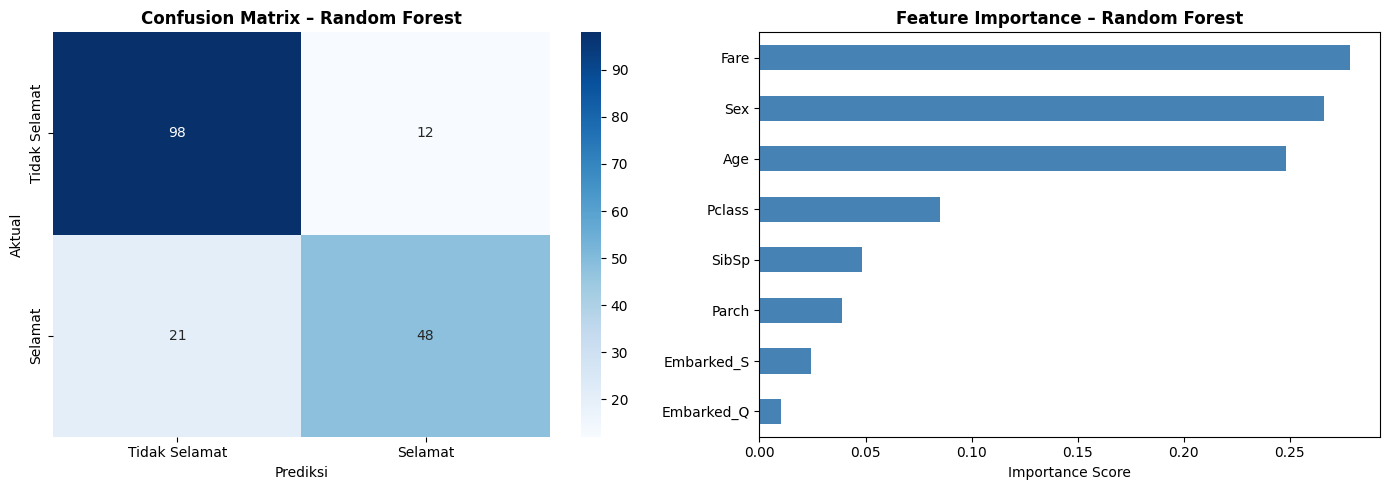


=== Classification Report – Random Forest ===
               precision    recall  f1-score   support

Tidak Selamat       0.82      0.89      0.86       110
      Selamat       0.80      0.70      0.74        69

     accuracy                           0.82       179
    macro avg       0.81      0.79      0.80       179
 weighted avg       0.81      0.82      0.81       179



In [19]:
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Tidak Selamat', 'Selamat'],
            yticklabels=['Tidak Selamat', 'Selamat'])
axes[0].set_title('Confusion Matrix – Random Forest', fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Feature Importance
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance – Random Forest', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print('\n=== Classification Report – Random Forest ===')
print(classification_report(y_test, y_pred_best, target_names=['Tidak Selamat', 'Selamat']))